# Data Explorer

This notebook provides a structured, reproducible exploratory analysis of the dataset.

It serves as a principled first diagnostic pass, focusing on scale, structure, concentration, and distributional properties.

---

## Questions addressed

1. **Scale and temporal coverage**
   - How large is the dataset?
   - Over what time period does it span?

2. **Participation structure**
   - How concentrated is activity across **sources**?
   - How concentrated is activity across **users**?

3. **Heavy-tailed behaviour**
   - Do participation distributions resemble power-law behaviour?
   - Is activity dominated by a small minority of actors?

4. **Temporal dynamics**
   - Does cumulative posting grow approximately linearly?
   - Is activity steady or bursty over time?

5. **Weight distribution**
   - What is the empirical distribution of article-level weights?
   - Does it resemble a Gaussian distribution?
   - Are there signs of skewness or heavy tails?

---

## Outputs

All generated figures are saved to the `images/` directory:

- `source_participation.png`
- `user_participation.png`
- `cumulative_tweets.png`
- `distribution_weights.png`


## 1) Load dataset

Load the raw CSV and display it for a quick sanity check.

Expected columns (minimum):
- `timestamp` (parseable date/time)
- `tweet_id` (article identifier)
- `user` (reposter / account)
- `source` (origin / publisher / upstream account)
- `weight` (numeric score per `tweet_id`)


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import LogLocator, FuncFormatter

import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("../data/data.csv")
df

,source,user,timestamp,tweet_id,weight
0,113773,1582,2020-02-02 02:20:12+00:00,1223789646989144065,0.308981
1,113773,2844,2020-02-02 02:09:37+00:00,1223789646989144065,0.308981
2,113773,3340,2020-02-02 02:58:23+00:00,1223789646989144065,0.308981
3,113773,5587,2020-02-02 02:06:39+00:00,1223789646989144065,0.308981
4,113773,8658,2020-02-02 11:27:08+00:00,1223789646989144065,0.308981
...,...,...,...,...,...
180298,84832,53623,2020-07-31 13:53:53+00:00,1288987370637930496,0.434849
180299,84832,74029,2020-07-31 13:14:38+00:00,1288987370637930496,0.434849
180300,84832,75627,2020-07-31 03:15:49+00:00,1288987370637930496,0.434849
180301,84832,84161,2020-07-31 01:14:10+00:00,1288987370637930496,0.434849


## 2) Summary statistics

We compute:

### Scale / coverage
- total rows
- unique users
- unique tweet IDs
- unique sources
- start/end date and time span

### Distribution summaries
For each distribution we report: mean, median, mode, std, min, max.

Distributions:
- **Tweet IDs per user**: how many distinct articles each user reposts.
- **Users per tweet ID**: how many distinct users repost each article.
- **Tweets per day**: daily posting volume.
- **Weight per tweet ID**: one weight value per article (`tweet_id`), using the first weight seen (swap to mean if weight varies within `tweet_id`).


In [3]:
# --- Prep ---
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

def mode_value(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return np.nan
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

def summary_stats(s: pd.Series):
    s = s.dropna()
    return {
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode": mode_value(s),
        "Std": s.std(),
        "Min": s.min(),
        "Max": s.max(),
    }

# --- Scale / coverage ---
scale_rows = [
    ("Scale", "Rows (tweets)", f"{len(df):,}"),
    ("Scale", "Unique users", f"{df['user'].nunique():,}"),
    ("Scale", "Unique tweet IDs", f"{df['tweet_id'].nunique():,}"),
    ("Scale", "Unique sources", f"{df['source'].nunique():,}"),
    ("Scale", "Start date", df["timestamp"].min().date()),
    ("Scale", "End date", df["timestamp"].max().date()),
    ("Scale", "Time span (days)", (df["timestamp"].max() - df["timestamp"].min()).days + 1),
]

# --- Distributions ---
tweets_per_user = df.groupby("user")["tweet_id"].nunique().astype(float)
users_per_tweet_id = df.groupby("tweet_id")["user"].nunique().astype(float)

df_time = df.dropna(subset=["timestamp"]).set_index("timestamp").sort_index()
tweets_per_day = df_time.resample("D").size().astype(float)

# --- Weight per tweet_id (one value per tweet_id) ---
df_w = df.copy()
df_w["weight"] = pd.to_numeric(df_w["weight"], errors="coerce")

weights_per_tweet_id = (
    df_w.dropna(subset=["tweet_id", "weight"])
        .groupby("tweet_id")["weight"]
        .first()
        .astype(float)
)

# --- Build table ---
rows = []
rows.extend(scale_rows)

for section, series in [
    ("Tweet IDs per user", tweets_per_user),
    ("Users per tweet ID", users_per_tweet_id),
    ("Tweets per day", tweets_per_day),
    ("Weight (per tweet ID)", weights_per_tweet_id),
]:
    stats = summary_stats(series)
    for k in ["Mean", "Median", "Mode", "Std", "Min", "Max"]:
        rows.append((section, k, stats[k]))

summary_table = pd.DataFrame(rows, columns=["Section", "Statistic", "Value"])
summary_table


,Section,Statistic,Value
0,Scale,Rows (tweets),"180,303"
1,Scale,Unique users,"118,987"
2,Scale,Unique tweet IDs,"1,326"
3,Scale,Unique sources,772
4,Scale,Start date,2020-02-02
5,Scale,End date,2020-07-31
6,Scale,Time span (days),181
7,Tweet IDs per user,Mean,1.462109
8,Tweet IDs per user,Median,1.0
9,Tweet IDs per user,Mode,1.0


## 3) Source participation (histogram + power-law diagnostic)

This cell quantifies how concentrated posting activity is across **sources**.

### What is measured
For each `source`, compute the number of **distinct** `tweet_id`s it appears in:

- `df.groupby("source")["tweet_id"].nunique()`

So each source gets a single integer count: “how many unique articles were posted by this source”.

### What is plotted
A histogram of these counts (sources on the y-axis, “articles posted” on the x-axis), with the y-axis shown on a **log scale** to make the long tail visible.

This reveals whether activity is:
- roughly uniform,
- moderately skewed,
- or strongly heavy-tailed (few very dominant sources).

### Power-law fit (diagnostic, not a formal test)

We fit a simple power law to the binned histogram counts:

$$
y = a x^{-b}
$$

by linear regression in log–log space:

$$
\log y = \log a - b \log x
$$

and report:
- fitted parameters \(a\) and \(b\)
- \(R^2\) computed in log–log space

**Important:**  
This is a visual diagnostic only. A true power-law test would require:
- tail threshold estimation,
- maximum likelihood estimation,
- and goodness-of-fit comparison (e.g. vs lognormal).

### Interpretation guide

- Larger \(b\) → steeper drop-off (less extreme concentration).
- Smaller \(b\) → heavier tail (more concentration among a few sources).
- High log–log \(R^2\) → distribution approximately linear in log–log space (suggestive of heavy-tailed behaviour).

### Output

The figure is saved to:

- `images/source_participation.png`


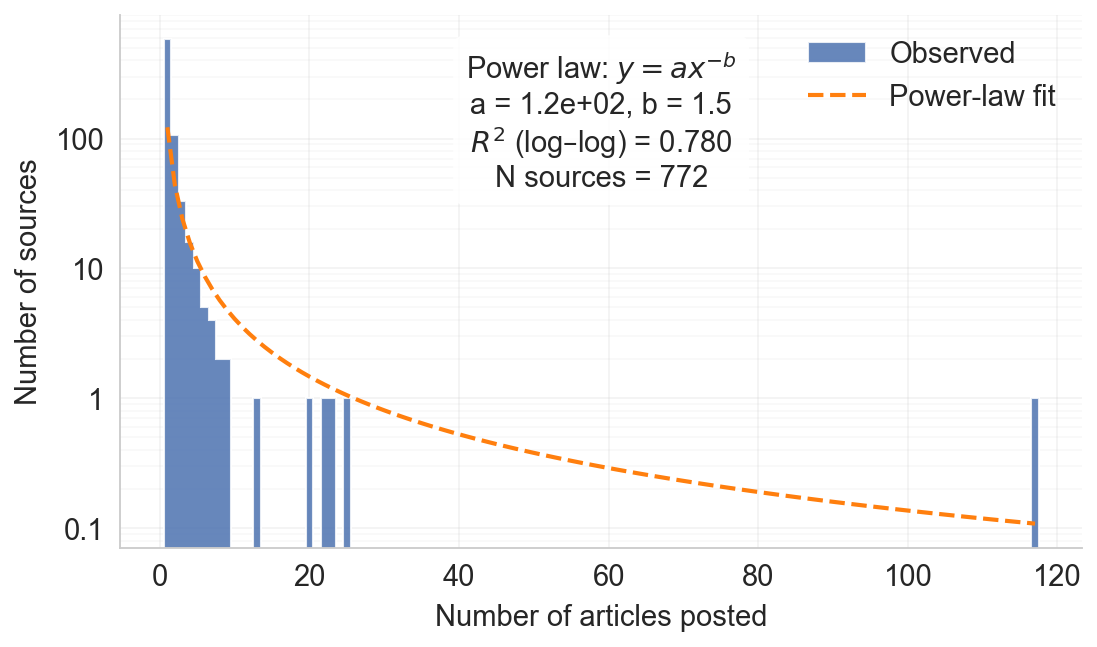

In [4]:
sns.set_theme(style="whitegrid", context="paper")

# -----------------------------
# Global "publication" styling
# -----------------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.figsize": (7.2, 4.2),
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 10,
    "axes.linewidth": 0.9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 10,
    "axes.labelpad": 6,
})

def _thousands(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:g}M"
    if x >= 1_000:
        return f"{x/1_000:g}k"
    return f"{int(x)}" if float(x).is_integer() else f"{x:g}"

def prettify_axes(ax):
    ax.grid(True, which="major", axis="both")
    ax.grid(True, which="minor", axis="both", alpha=0.12)
    ax.tick_params(which="both", direction="out", length=4)
    ax.tick_params(which="minor", length=2)
    ax.yaxis.set_major_formatter(FuncFormatter(_thousands))
    return ax

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# -----------------------------
# User participation histogram + power-law fit
# -----------------------------
user_tweet_counts = df.groupby("source")["tweet_id"].nunique().dropna()

cmin, cmax = int(user_tweet_counts.min()), int(user_tweet_counts.max())
bins = np.arange(cmin, cmax + 2) - 0.5

counts, edges = np.histogram(user_tweet_counts.values, bins=bins)
x = (0.5 * (edges[:-1] + edges[1:])).astype(int)
y = counts.astype(int)

# Fit power law on positive bins: y = a * x^{-b}
mask = y > 0
x_fit = x[mask].astype(float)
y_fit = y[mask].astype(float)

Xp = np.log(x_fit)
Yp = np.log(y_fit)
slope, loga = np.polyfit(Xp, Yp, 1)  # log y = slope * log x + log a
a = float(np.exp(loga))
b = float(-slope)

y_hat_fit = a * (x_fit ** (-b))
r2_loglog = r2(Yp, np.log(y_hat_fit))

# Model curve across all x (avoid x=0; here x starts at 1 anyway)
y_model = a * (x.astype(float) ** (-b))

fit_text = (
    "Power law: $y = a x^{-b}$\n"
    f"a = {a:.2g}, b = {b:.2g}\n"
    f"$R^2$ (log–log) = {r2_loglog:.3f}"
)

# Plot
fig, ax = plt.subplots(constrained_layout=True)

ax.hist(
    user_tweet_counts.values,
    bins=bins,
    histtype="stepfilled",
    linewidth=1.0,
    alpha=0.85,
    label="Observed",
)

ax.plot(
    x,
    y_model,
    linestyle="--",
    linewidth=2.0,
    color="tab:orange",
    label="Power-law fit",
)

ax.set_yscale("log")
ax.set_xlabel("Number of articles posted")
ax.set_ylabel("Number of sources")
#ax.set_title("User participation across trees")

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

ax.text(
    0.5, 0.8,
    fit_text + f"\nN sources = {len(user_tweet_counts):,}",
    transform=ax.transAxes,
    ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85),
)

ax.legend(frameon=False, fontsize=14)
prettify_axes(ax)

plt.savefig("images/source_participation.png", bbox_inches="tight")

plt.show()


## 4) User participation (histogram + power-law diagnostic)

This cell quantifies how concentrated reposting activity is across **users**.

### What is measured
For each `user`, compute the number of **distinct** `tweet_id`s they repost:

- `df.groupby("user")["tweet_id"].nunique()`

Each user therefore gets a single integer count: “how many unique articles this user reposted”.

### What is plotted
A histogram of user repost-counts:
- x-axis: number of reposted articles (distinct `tweet_id`s)
- y-axis: number of users with that repost-count

The y-axis is displayed on a **log scale** so that the long tail (high-activity users) remains visible.

### Power-law fit (diagnostic, not a formal test)

We fit a simple power law to the binned histogram counts:

$$
y = a x^{-b}
$$

via linear regression in log–log space:

$$
\log y = \log a - b \log x
$$

and report:
- fitted parameters \(a\) and \(b\)
- \(R^2\) computed in log–log space

### Styling
This cell applies a consistent “publication” Matplotlib style (font sizes, grid, spines) and formats large counts using `k` / `M` suffixes.  
Legend font size is set explicitly via `ax.legend(..., fontsize=14)` to avoid rcParam surprises.

### Output
The figure is saved to:

- `images/user_participation.png`


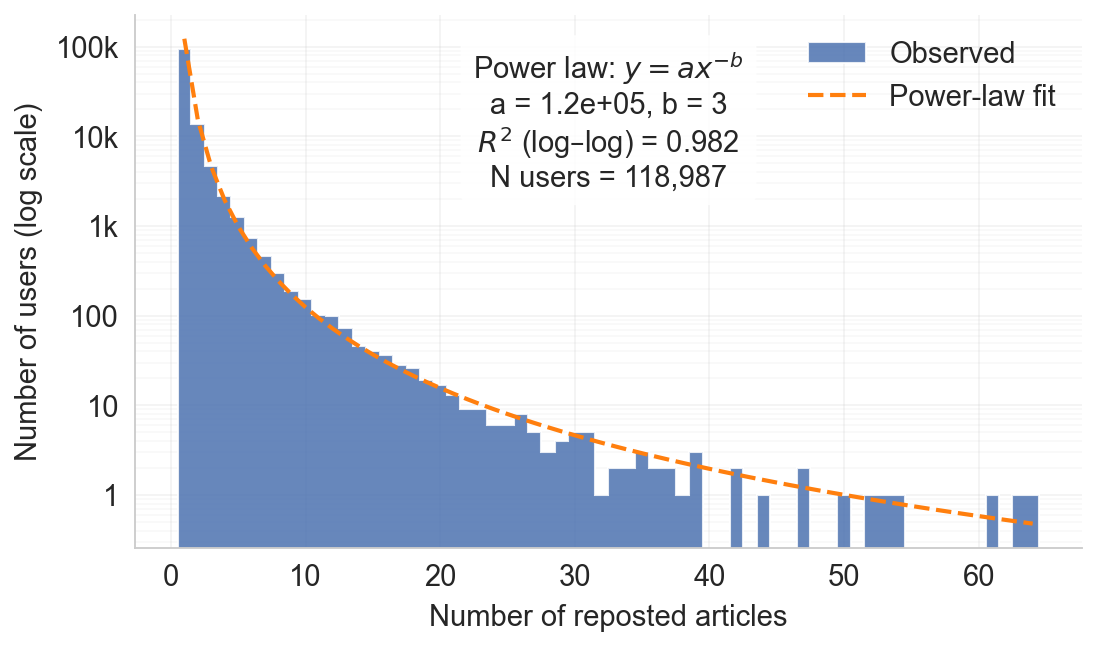

In [5]:
# -----------------------------
# Global "publication" styling
# -----------------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.figsize": (7.2, 4.2),
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 10,
    "axes.linewidth": 0.9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 10,
    "axes.labelpad": 6,
})

def _thousands(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:g}M"
    if x >= 1_000:
        return f"{x/1_000:g}k"
    return f"{int(x)}" if float(x).is_integer() else f"{x:g}"

def prettify_axes(ax):
    ax.grid(True, which="major", axis="both")
    ax.grid(True, which="minor", axis="both", alpha=0.12)
    ax.tick_params(which="both", direction="out", length=4)
    ax.tick_params(which="minor", length=2)
    ax.yaxis.set_major_formatter(FuncFormatter(_thousands))
    return ax

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# -----------------------------
# User participation histogram + power-law fit
# -----------------------------
user_tweet_counts = df.groupby("user")["tweet_id"].nunique().dropna()

cmin, cmax = int(user_tweet_counts.min()), int(user_tweet_counts.max())
bins = np.arange(cmin, cmax + 2) - 0.5

counts, edges = np.histogram(user_tweet_counts.values, bins=bins)
x = (0.5 * (edges[:-1] + edges[1:])).astype(int)
y = counts.astype(int)

# Fit power law on positive bins: y = a * x^{-b}
mask = y > 0
x_fit = x[mask].astype(float)
y_fit = y[mask].astype(float)

Xp = np.log(x_fit)
Yp = np.log(y_fit)
slope, loga = np.polyfit(Xp, Yp, 1)  # log y = slope * log x + log a
a = float(np.exp(loga))
b = float(-slope)

y_hat_fit = a * (x_fit ** (-b))
r2_loglog = r2(Yp, np.log(y_hat_fit))

# Model curve across all x (avoid x=0; here x starts at 1 anyway)
y_model = a * (x.astype(float) ** (-b))

fit_text = (
    "Power law: $y = a x^{-b}$\n"
    f"a = {a:.2g}, b = {b:.2g}\n"
    f"$R^2$ (log–log) = {r2_loglog:.3f}"
)

# Plot
fig, ax = plt.subplots(constrained_layout=True)

ax.hist(
    user_tweet_counts.values,
    bins=bins,
    histtype="stepfilled",
    linewidth=1.0,
    alpha=0.85,
    label="Observed",
)

ax.plot(
    x,
    y_model,
    linestyle="--",
    linewidth=2.0,
    color="tab:orange",
    label="Power-law fit",
)

ax.set_yscale("log")
ax.set_xlabel("Number of reposted articles")
ax.set_ylabel("Number of users (log scale)")
#ax.set_title("User participation across trees")

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

ax.text(
    0.5, 0.8,
    fit_text + f"\nN users = {len(user_tweet_counts):,}",
    transform=ax.transAxes,
    ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85),
)

ax.legend(frameon=False, fontsize=14)
prettify_axes(ax)

plt.savefig("images/user_participation.png", bbox_inches="tight")

plt.show()


## 5) Cumulative posting volume over time (trend analysis)

This cell examines how total posting activity accumulates over time.

### Data preparation

- Convert `timestamp` to UTC datetime.
- Drop rows with invalid timestamps.
- Resample to **daily counts**.
- Compute the **cumulative sum** of daily volume.

This produces a monotone time series:

$$
Y(t) = \sum_{s \le t} \text{daily posts}(s)
$$

### Linear trend model

We regress cumulative volume against time (measured in days since start):

$$
Y(t) = \alpha + \beta t
$$

where:

- \( \beta \) = average posts per day  
- \( \alpha \) = intercept  
- \( R^2 \) = goodness of fit  
- p-value tests \( \beta \neq 0 \)

The residual standard deviation is also reported to quantify deviation from a purely linear growth process.

### Interpretation

- High \( R^2 \) → posting grows approximately linearly (steady rate).
- Low \( R^2 \) → bursts, regime shifts, or acceleration effects.
- Large residual variance → temporal clustering or structural breaks.

A perfectly linear cumulative curve implies stationary daily posting intensity.

### Output

The figure is saved to:

- `images/cumulative_tweets.png`

The regression statistics are also printed below the plot for direct reuse.


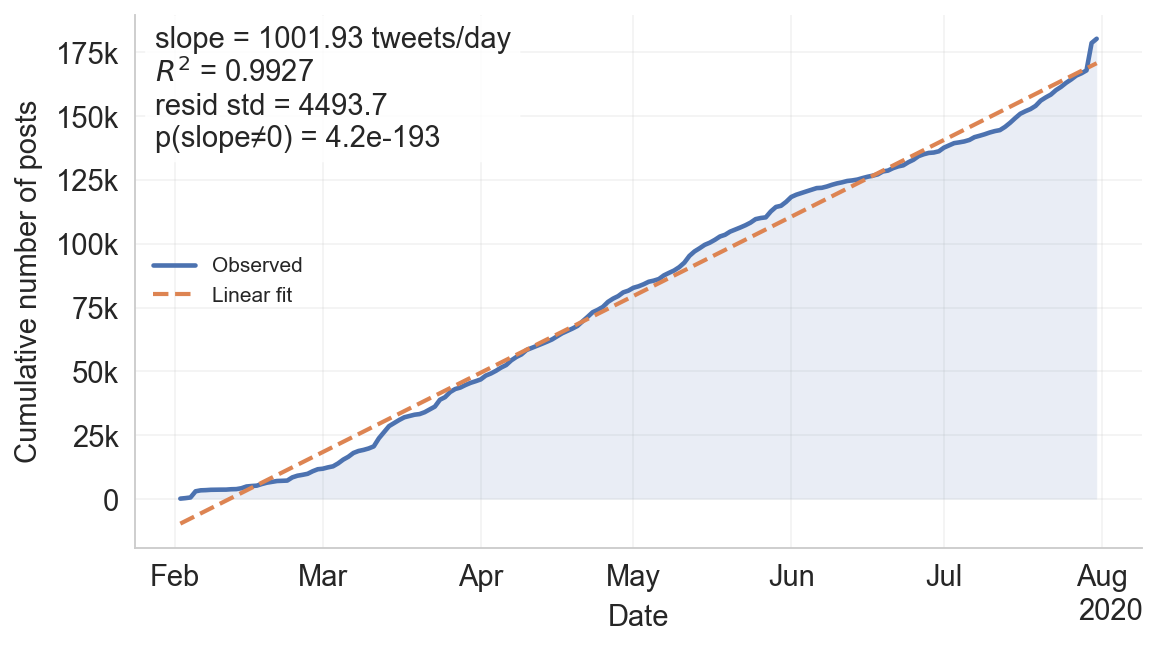

In [6]:
from scipy import stats
# -----------------------------
# Cumulative tweet volume over time with linear fit
# -----------------------------
df_all = df.copy()
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce", utc=True)
df_time = df_all.dropna(subset=["timestamp"]).copy()

tweet_volume = (
    df_time.set_index("timestamp")
    .sort_index()
    .resample("D")
    .size()
)

cumulative_volume = tweet_volume.cumsum()

# Convert dates to numeric (days since start)
t = (cumulative_volume.index - cumulative_volume.index[0]).days.values.astype(float)
y = cumulative_volume.values.astype(float)

# Linear regression
slope, intercept, r_value, p_value, stderr = stats.linregress(t, y)
r2 = r_value**2

# Predicted line
y_hat = intercept + slope * t

# Residual standard deviation
resid_std = np.std(y - y_hat)

fig, ax = plt.subplots(constrained_layout=True, figsize=(7.6, 4.2))

ax.plot(cumulative_volume.index, y, linewidth=2.2, label="Observed")
ax.plot(cumulative_volume.index, y_hat, linestyle="--", linewidth=2.0, label="Linear fit")
ax.fill_between(cumulative_volume.index, y, alpha=0.12)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative number of posts")
#ax.set_title("Cumulative Tweet Volume Over Time")

ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.yaxis.set_major_formatter(FuncFormatter(_thousands))

# Annotation box
text = (
    f"slope = {slope:.2f} tweets/day\n"
    f"$R^2$ = {r2:.4f}\n"
    f"resid std = {resid_std:.1f}\n"
    f"p(slope≠0) = {p_value:.2g}"
)

ax.text(
    0.02, 0.98,
    text,
    transform=ax.transAxes,
    ha="left", va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
)

ax.legend(frameon=False)
prettify_axes(ax)

plt.savefig("images/cumulative_tweets.png", bbox_inches="tight")

plt.show()


## 6) Weight distribution (Gaussian fit and normality diagnostics)

This cell examines the distribution of `weight` values, using **one weight per `tweet_id`**.

### Data preparation

- Coerce `weight` to numeric.
- Drop missing values.
- Aggregate to one value per `tweet_id`

Let:

$$
W = \{ w_1, \dots, w_n \}
$$

be the resulting vector of article-level weights.

---

### Histogram + Gaussian fit

We:

1. Plot a histogram (counts, not density).
2. Fit a normal distribution:

$$
W \sim \mathcal{N}(\mu, \sigma)
$$

using maximum likelihood estimation.
3. Overlay the fitted Gaussian curve, scaled to match histogram counts.

---

### Reported statistics

- \( \mu \) — mean of fitted normal  
- \( \sigma \) — standard deviation  
- Skewness — symmetry (0 for normal)  
- Kurtosis (Fisher definition) — tail heaviness (0 for normal)  
- Shapiro–Wilk p-value — normality test (computed on up to 5000 samples)  
- Number of unique `tweet_id`s  

---

### Interpretation guide

- **Skew ≠ 0** → asymmetric distribution  
- **Kurtosis > 0** → heavier tails than normal  
- **Small Shapiro p-value** → reject normality  

For large \( n \), Shapiro–Wilk will almost always reject exact normality. Treat it as a structural diagnostic, not a definitive verdict.

---

### Output

The figure is saved to:

- `images/distribution_weights.png`

Summary statistics are printed below the plot for reuse.


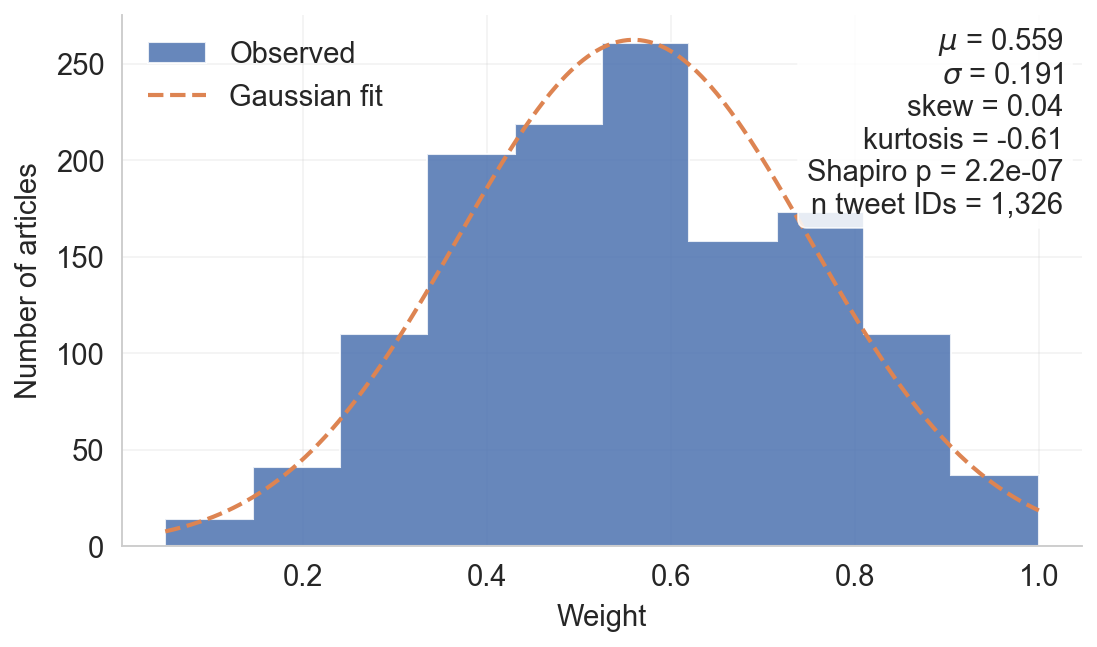

In [7]:
# -----------------------------
# Weight distribution with Gaussian fit (one weight per tweet_id)
# -----------------------------
df_w = df_all.copy()

# Ensure numeric weights
df_w["weight"] = pd.to_numeric(df_w["weight"], errors="coerce")

# One weight per tweet_id:
# - if weight is constant within tweet_id, 'first' is fine
# - if not, switch to .mean() (commented below)
weights_by_tweet = (
    df_w.dropna(subset=["tweet_id", "weight"])
        .groupby("tweet_id")["weight"]
        .first()
)

weights = weights_by_tweet.values

NBINS = 10

# Fit normal distribution
mu, sigma = stats.norm.fit(weights)

# Summary stats 
skew = stats.skew(weights)
kurt = stats.kurtosis(weights, fisher=True)
shapiro_stat, shapiro_p = stats.shapiro(weights[: min(5000, len(weights))])

fig, ax = plt.subplots(constrained_layout=True)

# Histogram (counts)
counts, bins, _ = ax.hist(
    weights,
    bins=NBINS,
    histtype="stepfilled",
    linewidth=1.0,
    alpha=0.85,
    label="Observed",
)

# Fitted Gaussian, scaled to counts
x = np.linspace(bins[0], bins[-1], 400)
bin_width = bins[1] - bins[0]
pdf = stats.norm.pdf(x, mu, sigma)
ax.plot(
    x,
    pdf * len(weights) * bin_width,
    linestyle="--",
    linewidth=2.0,
    label="Gaussian fit",
)

ax.set_xlabel("Weight")
ax.set_ylabel("Number of articles")

text = (
    f"$\\mu$ = {mu:.3g}\n"
    f"$\\sigma$ = {sigma:.3g}\n"
    f"skew = {skew:.2f}\n"
    f"kurtosis = {kurt:.2f}\n"
    f"Shapiro p = {shapiro_p:.2g}\n"
    f"n tweet IDs = {len(weights):,}"
)

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85),
)

ax.legend(frameon=False, fontsize=14)

plt.savefig("images/distribution_weights.png", bbox_inches="tight")
plt.show()